In [1]:
from spin_lattices import SpinLattice, KagomeLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from pathlib import Path
from vmc_amplitude import apply_off_diag_to_basis_states, apply_diag_to_basis_states
from scipy.sparse import csr_matrix, diags, eye
import numpy as np
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

2023-09-08 21:35:55.832 | DEBUG    | lattice_symmetries:__init__:50 - Initializing Haskell runtime...
2023-09-08 21:35:55.911 | DEBUG    | lattice_symmetries:__init__:52 - Initializing Chapel runtime...
2023-09-08 21:35:55.986 | DEBUG    | lattice_symmetries:__init__:54 - Setting Python exception handler...
set_python_exception_handler ...


In [2]:
lattice = KagomeLattice(2, 3)
system = HeisenbergJ1J2(lattice, 1, 1, use_symmetries=False, spin_inversion=None)
system.get_eigenstates(1)

2023-09-08 21:36:05.743 | DEBUG    | heisenberg_hamiltonians:__init__:482 - number_spins=18
2023-09-08 21:36:05.754 | DEBUG    | heisenberg_hamiltonians:__init__:492 - Symmetry group contains 0 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-09-08 21:36:05.795 | DEBUG    | heisenberg_hamiltonians:__init__:501 - Hilbert space dimension is 48620
2023-09-08 21:36:05.842 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-False-None-1.pickle
2023-09-08 21:36:05.845 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:121 - Ground state energy is -32.1930830942


(array([-32.19308309]),
 array([[ 4.67734071e-06],
        [ 4.05907513e-05],
        [-1.98695729e-05],
        ...,
        [ 1.98695729e-05],
        [-4.05907513e-05],
        [-4.67734071e-06]]))

In [3]:
def get_csr_hamiltonian(system: SpinSystem):
    states, coeffs, row_idxs = apply_off_diag_to_basis_states(
        system.hamiltonian, system.basis.states
    )
    columns = system.basis.index(states)
    upper_triangular = csr_matrix(
        (coeffs, columns, row_idxs),
        shape=(system.basis.states.shape[0], system.basis.states.shape[0]),
    )
    diagonal = diags(
        apply_diag_to_basis_states(system.hamiltonian, system.basis.states)
    )
    return (upper_triangular + diagonal).real

In [4]:
H = get_csr_hamiltonian(system)

In [5]:
eigsh(H, which="SA", k=1)

(array([-32.19308309]),
 array([[ 4.67734071e-06],
        [ 4.05907513e-05],
        [-1.98695729e-05],
        ...,
        [ 1.98695729e-05],
        [-4.05907513e-05],
        [-4.67734071e-06]]))

In [6]:
ground_state = system.get_ground_state_coeffs(system.basis.states)
signs = np.sign(ground_state)
H_corrected = diags(signs) @ H @ diags(signs)

In [7]:
def overlap(x, y):
    return x @ y / (np.linalg.norm(x) * np.linalg.norm(y))

In [8]:
signs = np.sign(ground_state)
H_corrected = diags(signs) @ H @ diags(signs)
overlaps_power = []
for shift in [0, 10, 50, 500, 5000]:
    H_corrected_shifted = shift * eye(H_corrected.shape[0]) - H_corrected

    x = np.random.uniform(0, 1, size=H_corrected.shape[0])
    noise_level = 0.0
    for i in range(200):
        # noise = np.random.uniform(-noise_level, noise_level, size=x.shape[0])
        x = H_corrected_shifted @ x
        x = x / np.linalg.norm(x)
        x = np.abs(x)
        print(i, overlap(x, np.abs(ground_state)))
        overlaps_power.append({'shift': shift, 'iteration': i, 'overlap': overlap(x, np.abs(ground_state))})

0 0.7319776480087828
1 0.8833042299905579
2 0.942526954525347
3 0.9677979593276319
4 0.9797887049780336
5 0.9860762734909984
6 0.9896539090978455
7 0.9918309474775965
8 0.9932396401073716
9 0.9941977769506015
10 0.9948834309108918
11 0.9953929548232416
12 0.9957885710408928
13 0.9961039535618323
14 0.9963645248282418
15 0.9965833170589711
16 0.9967719974749033
17 0.9969363676578202
18 0.9970822289499718
19 0.9972124560363644
20 0.9973303759587205
21 0.9974373200810466
22 0.9975356237342825
23 0.9976256238155164
24 0.9977092752891942
25 0.9977864158048511
26 0.9978586800020288
27 0.9979256736005797
28 0.9979887321211139
29 0.9980474473887107
30 0.9981028410160744
31 0.9981545735739463
32 0.9982034618844099
33 0.9982492070010444
34 0.9982925092639381
35 0.9983329596601025
36 0.998371349315041
37 0.9984070800479647
38 0.9984410230673367
39 0.9984724764503542
40 0.9985023640784315
41 0.9985298678638669
42 0.9985559833937112
43 0.9985797604515894
44 0.9986023145751785
45 0.9986225625835293


In [9]:
pd.DataFrame(overlaps_power)

,shift,iteration,overlap
0,0,0,0.731978
1,0,1,0.883304
2,0,2,0.942527
3,0,3,0.967798
4,0,4,0.979789
...,...,...,...
995,5000,195,0.694503
996,5000,196,0.695770
997,5000,197,0.697033
998,5000,198,0.698292


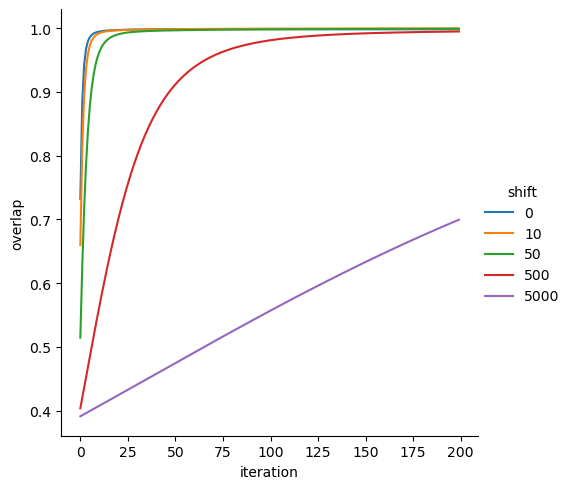

In [10]:
sns.relplot(
    pd.DataFrame(overlaps_power).assign(shift=lambda df: df["shift"].astype(str)),
    x="iteration",
    y="overlap",
    hue="shift",
    kind="line",
)

In [9]:
signs = np.sign(ground_state)
H_corrected = diags(signs) @ H @ diags(signs)
H_corrected_shifted = 50 * eye(H_corrected.shape[0]) - H_corrected
psi_0 = np.random.uniform(0, 1, size=H_corrected.shape[0])
psi_0 = psi_0 / np.linalg.norm(psi_0)
overlaps_lanczos = []

for i in range(200):
    H_psi_0 = H_corrected_shifted @ psi_0
    psi_1 = H_psi_0
    psi_1 = psi_1 - psi_1 @ psi_0 * psi_0
    psi_1 = psi_1 / np.linalg.norm(psi_1)

    H_psi_1 = H_corrected_shifted @ psi_1
    a11 = psi_0 @ H_psi_0
    a12 = psi_0 @ H_psi_1
    a22 = psi_1 @ H_psi_1

    H_restricted = np.array([[a11, a12], [a12, a22]])
    eigenvalues, eigenvectors = np.linalg.eigh(H_restricted)
    # print(eigenvalues, eigenvectors)

    psi_0 = eigenvectors[0, 1] * psi_0 + eigenvectors[1, 1] * psi_1
    psi_0 = psi_0 / np.linalg.norm(psi_0)
    psi_0 = np.abs(psi_0)

    print(i, overlap(psi_0, np.abs(ground_state)))
    overlaps_lanczos.append(overlap(psi_0, np.abs(ground_state)))

0 0.7130578410786514
1 0.892832549508928
2 0.9433937551523347
3 0.9695092079699288
4 0.9792538479885003
5 0.9859604941679038
6 0.9889364053110146
7 0.9912452211850953
8 0.9924986100555452
9 0.9934908477197487
10 0.9941568473892577
11 0.9946888828187056
12 0.9950979924915165
13 0.9954386249263892
14 0.9957190621026583
15 0.9959630648881848
16 0.9961729203306999
17 0.9963610302144945
18 0.9965277004759858
19 0.9966800750136722
20 0.9968180178643407
21 0.9969458380794055
22 0.9970632436481158
23 0.997173078949416
24 0.9972749947362367
25 0.9973709468647591
26 0.9974606709986542
27 0.9975455836627563
28 0.9976254400137994
29 0.9977013149807702
30 0.997772978038124
31 0.9978412741055342
32 0.9979060136740947
33 0.9979678550575837
34 0.9980266576925011
35 0.9980829310613797
36 0.9981365651332155
37 0.998187983373808
38 0.9982370893445145
39 0.9982842399019061
40 0.9983293431063524
41 0.9983727095957986
42 0.9984142558118012
43 0.9984542569010019
44 0.9984926317294159
45 0.9985296291234992
46

In [13]:
def expected_value(x, H):
    return x @ H @ x / (x @ x)

In [19]:
signs = np.sign(ground_state)
H_corrected = diags(signs) @ H @ diags(signs)
# H_corrected_shifted = 50 * eye(H_corrected.shape[0]) - H_corrected
psi_0 = np.random.uniform(0, 1, size=H_corrected.shape[0])
psi_0 = psi_0 / np.linalg.norm(psi_0)
psi_0 *= 10
overlaps_lanczos_chen = []

for i in range(200):
    v = np.sqrt(expected_value(psi_0, H_corrected **2) - expected_value(psi_0, H_corrected) ** 2)

    H_psi_0 = H_corrected @ psi_0    
    psi_1 = H_psi_0
    psi_1 = psi_1 - expected_value(psi_0, H_corrected) * psi_0
    psi_1 = psi_1 / v
    # assert np.isclose(np.linalg.norm(psi_1), 1)

    r = (
        expected_value(psi_0, H_corrected**3)
        - 3 * expected_value(psi_0, H_corrected ** 2) * expected_value(psi_0, H_corrected)
        + 2 * expected_value(psi_0, H_corrected) ** 3
    )
    r = r / (2 * v**3)
    alpha = r - np.sqrt((r**2 + 1))

    psi_0 = psi_0 / np.sqrt(1 + alpha**2) + psi_1 * alpha / np.sqrt(1 + alpha**2)
    psi_0 = np.abs(psi_0)

    print(i, overlap(psi_0, np.abs(ground_state)), alpha)
    overlaps_lanczos_chen.append(overlap(psi_0, np.abs(ground_state)))

0 0.7068724554484784 -0.9706005686441197
1 0.8877611766715781 -0.518022964308146
2 0.9406290289837126 -0.22467073313658759
3 0.968582131433966 -0.15071458305866914
4 0.97898619821308 -0.08390030754362954
5 0.986210790419649 -0.06663099517600113
6 0.9893453015292154 -0.0417235068201407
7 0.9918117964916604 -0.035142196037377005
8 0.9930970105910729 -0.02504849642185647
9 0.9941310897202797 -0.021055897968143
10 0.9947965629993188 -0.017119988825687216
11 0.9953276318413613 -0.014451523423524293


KeyboardInterrupt: 

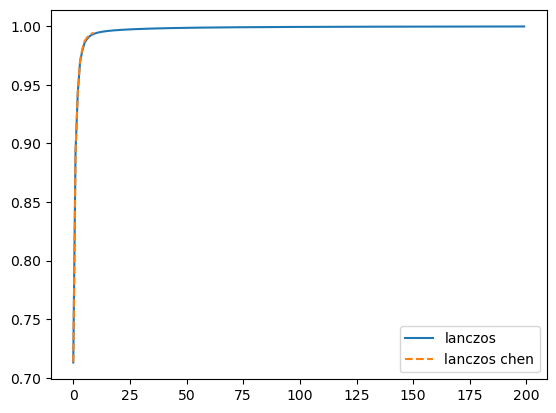

In [18]:
#plt.plot(overlaps_power, label="power")
plt.plot(overlaps_lanczos, label="lanczos")
plt.plot(overlaps_lanczos_chen, '--', label="lanczos chen")
plt.legend()

In [ ]:
def E_loc(H, psi):
    return H @ psi / psi

In [ ]:
psi_test = np.random.uniform(-1, 1, system.basis.states.shape[0])

In [ ]:
psi_test.shape

(48620,)

In [ ]:
def expected_value(H, psi):
    return (psi @ (H @ psi)) / (psi @ psi)

In [ ]:
E_loc(system.hamiltonian, psi_test) @ (psi_test ** 2) / (psi_test @ psi_test)

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152


-2.1157033458052013

In [ ]:
expected_value(system.hamiltonian, psi_test)

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152


-2.115703345805201

In [ ]:
expected_value(system.hamiltonian ** 2, psi_test)

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152
[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152


110.56163797860157

In [ ]:
(E_loc(system.hamiltonian, psi_test) ** 2) @ (psi_test ** 2) / (psi_test @ psi_test)

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152


110.56163797860158

In [ ]:
expected_value(system.hamiltonian ** 3, psi_test)

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152
[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152
[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152


-660.4831949098275

In [ ]:
(E_loc(system.hamiltonian, psi_test) ** 3) @ (psi_test ** 2) / (psi_test @ psi_test)

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152


-1064.089705216408